ENHANCED LOGISTIC REGRESSION FOR AQI PREDICTION

Loading dataset...
Dataset loaded: (29531, 16)

Processing missing values...
Encoding categorical variables...
Cities encoded: 26 unique cities
Target classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
Feature columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
Total features: 13

Scaling features...
Splitting dataset...
Train samples: 20671
Test samples: 8860

Applying SMOTE for class balancing...
After SMOTE - Train samples: 57030

DATA READY FOR TRAINING
Train samples: 57030
Test samples: 8860
Features: 13
Classes: 6
ENHANCED LOGISTIC REGRESSION - TRAINING WITH OPTIMAL PARAMETERS
Optimal Parameters:
  Learning Rate: 0.01
  Regularization: 0.01
  Batch Size: 128

TRAIN SET METRICS:
  Accuracy:  0.7548
  Precision: 0.7554
  Recall:    0.7548
  F1-Score:  0.7536

TEST SET METRICS:
  Accuracy:  0.7116
  Precision: 0.7533
  Recall:    0.7116
  F1-Score:  0.72

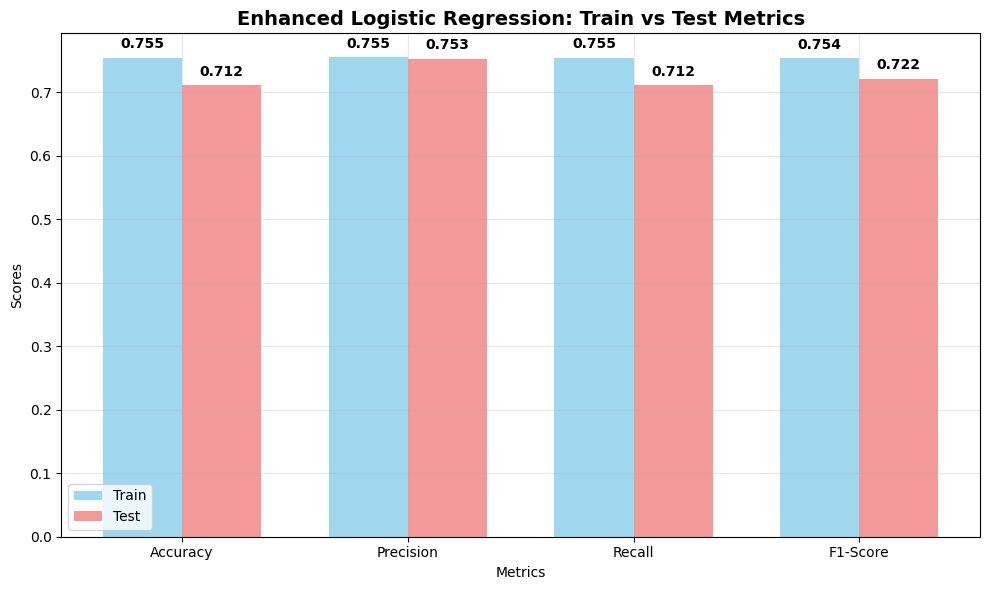

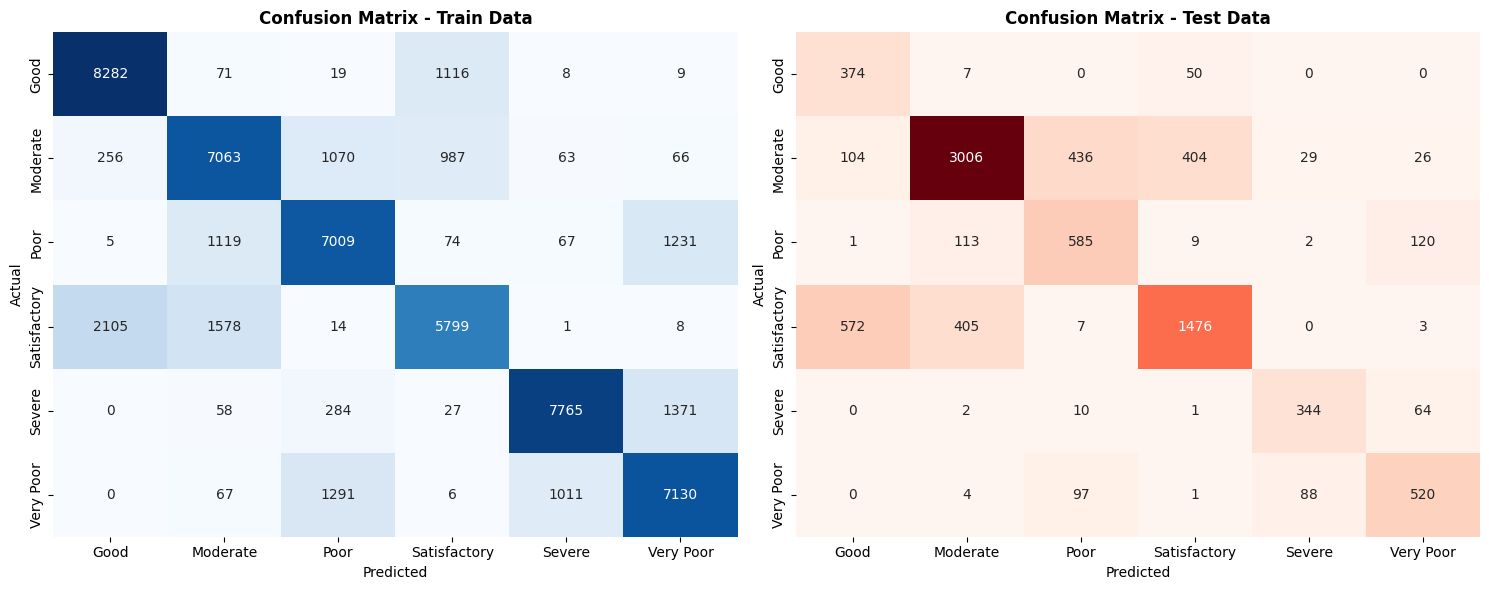

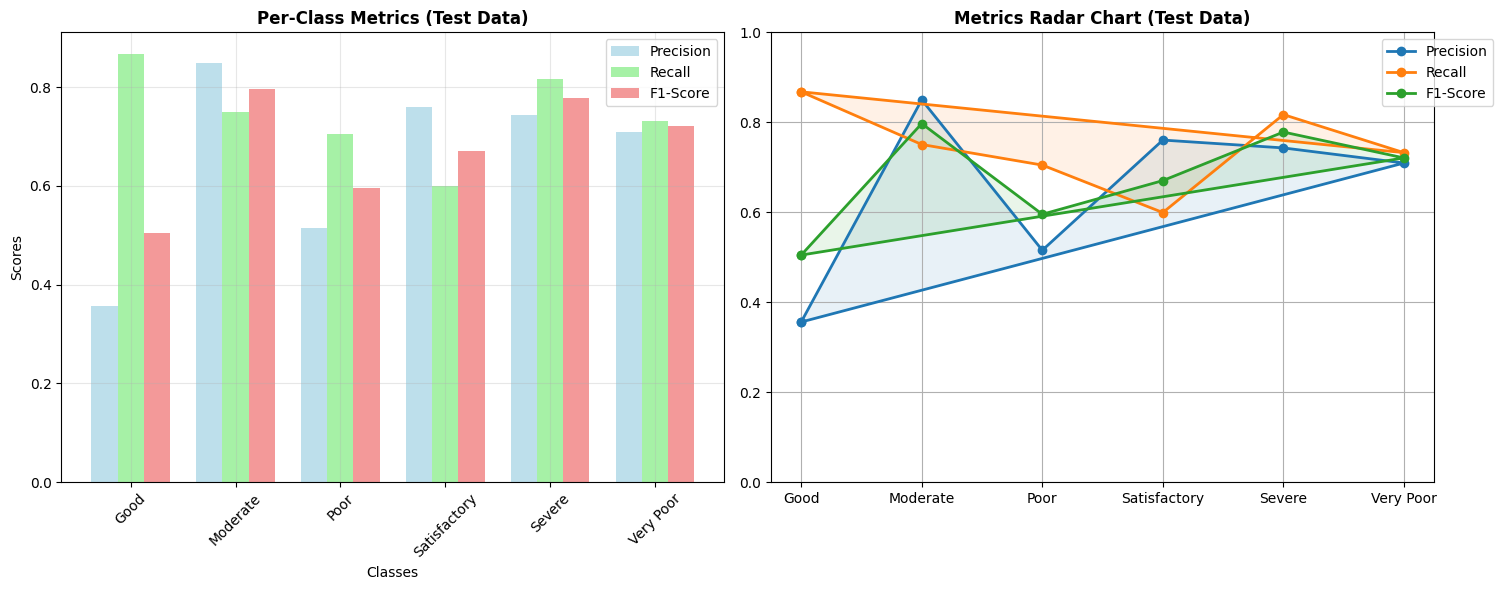

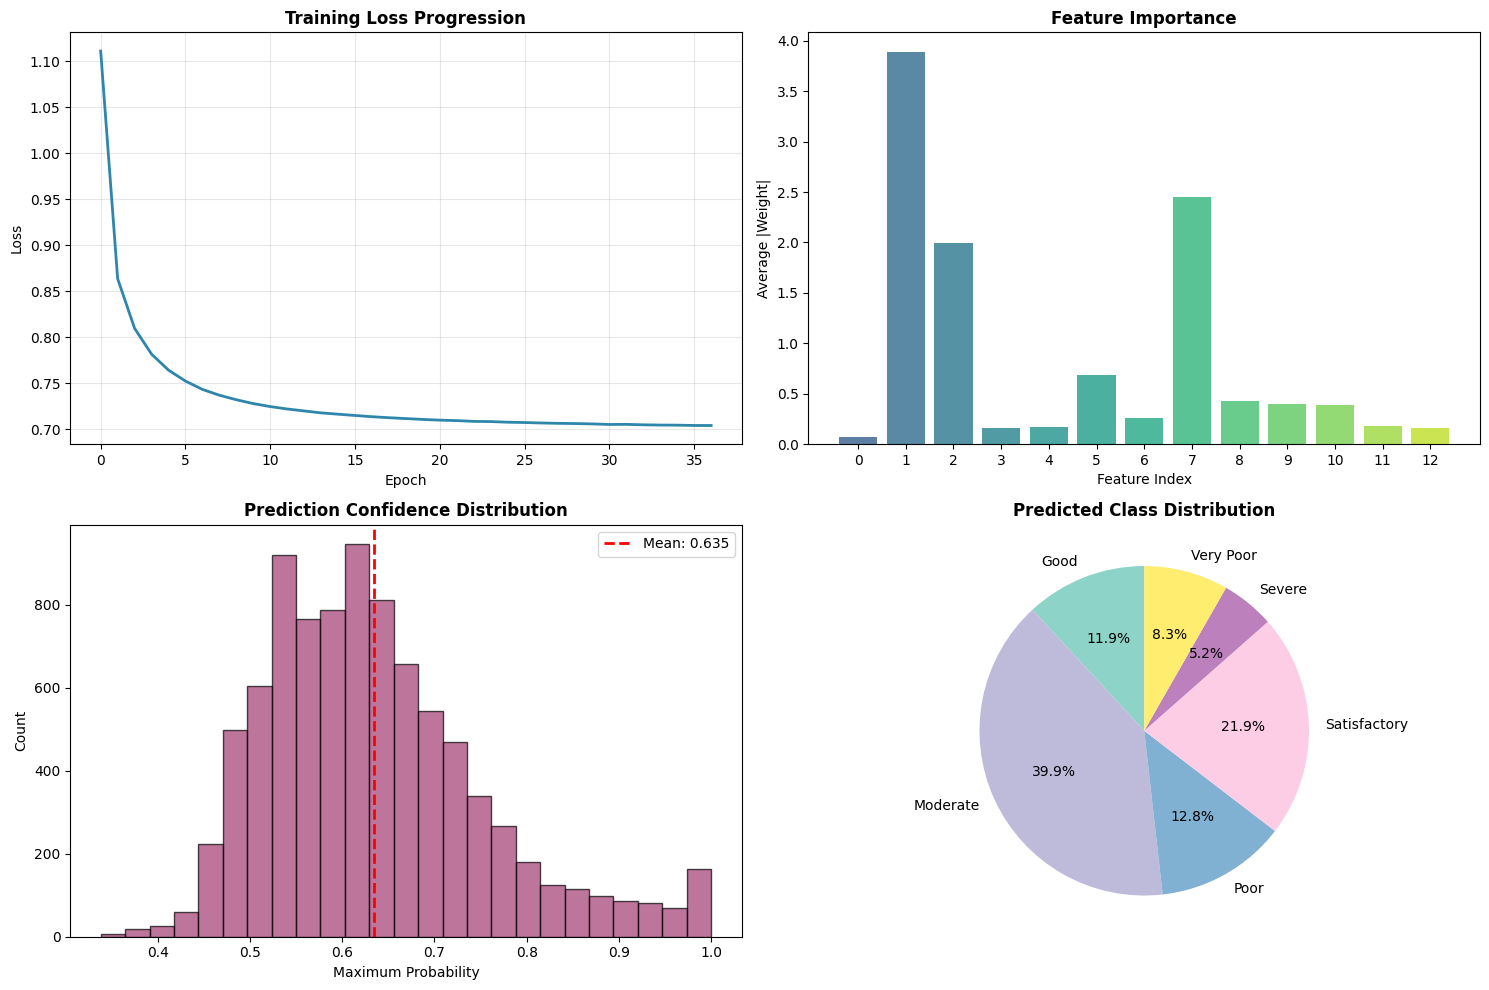


Top 5 Most Important Features:
  1. Feature 1: 3.8887
  2. Feature 7: 2.4522
  3. Feature 2: 1.9954
  4. Feature 5: 0.6829
  5. Feature 8: 0.4314

TRAINING COMPLETE!
Final Test Accuracy: 0.7116

Results Summary:
Dataset  Accuracy  Precision   Recall  F1-Score
  Train  0.754831   0.755378 0.754831  0.753599
   Test  0.711625   0.753311 0.711625  0.721736

Visualizations saved:
  - logistic_regression_metrics_comparison.png
  - logistic_regression_confusion_matrices.png
  - logistic_regression_detailed_metrics.png
  - logistic_regression_training_progress.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
warnings.filterwarnings('ignore')

# ==================== UTILITY CLASSES & FUNCTIONS ====================

class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

class LabelEncoder:
    def __init__(self):
        self.classes_ = None
        self.class_to_int = {}

    def fit(self, y):
        self.classes_ = np.unique(y)
        self.class_to_int = {c:i for i,c in enumerate(self.classes_)}
        return self

    def transform(self, y):
        return np.array([self.class_to_int[v] for v in y])

    def fit_transform(self, y):
        return self.fit(y).transform(y)

    def inverse_transform(self, yi):
        return np.array([self.classes_[int(i)] for i in yi])

def train_test_split(X, y, test_size=0.2, random_state=None, shuffle=True):
    X = np.asarray(X)
    y = np.asarray(y)
    n = len(X)
    if shuffle:
        rng = np.random.RandomState(random_state)
        idx = rng.permutation(n)
    else:
        idx = np.arange(n)
    split = int(n * (1 - test_size))
    train_idx, test_idx = idx[:split], idx[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

class SMOTE:
    def __init__(self, k_neighbors=5, random_state=None):
        self.k = k_neighbors
        self.random_state = np.random.RandomState(random_state)

    def fit_resample(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        classes, counts = np.unique(y, return_counts=True)
        max_count = counts.max()

        X_resampled = [X]
        y_resampled = [y]

        for cls, count in zip(classes, counts):
            X_cls = X[y == cls]
            if count < max_count:
                n_samples_needed = max_count - count
                synthetic_samples = self._generate_samples(X_cls, n_samples_needed)
                X_resampled.append(synthetic_samples)
                y_resampled.append(np.full(n_samples_needed, cls))

        X_res = np.vstack(X_resampled)
        y_res = np.concatenate(y_resampled)
        return X_res, y_res

    def _generate_samples(self, X, n_samples):
        n_minority = len(X)
        if n_minority == 0:
            return np.empty((0, X.shape[1]))
        k = min(self.k, n_minority - 1)
        synthetic = []
        for _ in range(n_samples):
            i = self.random_state.randint(0, n_minority)
            xi = X[i]
            distances = np.sqrt(((X - xi)**2).sum(axis=1))
            nn_indices = np.argsort(distances)[1:k+1]
            nn = X[self.random_state.choice(nn_indices)]
            diff = nn - xi
            gap = self.random_state.rand()
            synthetic.append(xi + gap * diff)
        return np.array(synthetic)


# ==================== ENHANCED LOGISTIC REGRESSION ====================

class EnhancedLogisticRegression:
    """
    Enhanced Multi-class Logistic Regression with:
    - Softmax for multi-class classification
    - L2 regularization
    - Mini-batch gradient descent
    - Momentum optimization
    - Adaptive learning rate
    - Early stopping with patience
    - Xavier initialization
    """
    def __init__(self, lr=0.01, epochs=3000, lambda_reg=0.1, tol=1e-4,
                 batch_size=None, momentum=0.9, random_state=None, verbose=True):
        self.lr = lr
        self.epochs = epochs
        self.lambda_reg = lambda_reg
        self.tol = tol
        self.batch_size = batch_size
        self.momentum = momentum
        self.random_state = random_state
        self.verbose = verbose
        self.loss_history = []
        self.velocity_W = None
        self.velocity_b = None

    def _softmax(self, z):
        """Numerically stable softmax"""
        z = np.clip(z, -500, 500)
        z = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z)
        return e / (e.sum(axis=1, keepdims=True) + 1e-15)

    def _cross_entropy_loss(self, y_true, y_pred, W):
        """Cross-entropy loss with L2 regularization"""
        n_samples = y_true.shape[0]
        epsilon = 1e-15
        loss = -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))
        loss += (self.lambda_reg / (2 * n_samples)) * np.sum(W ** 2)
        return loss

    def _learning_rate_schedule(self, epoch, initial_lr):
        """Adaptive learning rate with smoother decay"""
        if epoch > 2500:
            return initial_lr * 0.05
        elif epoch > 2000:
            return initial_lr * 0.1
        elif epoch > 1000:
            return initial_lr * 0.3
        elif epoch > 500:
            return initial_lr * 0.5
        else:
            return initial_lr

    def fit(self, X, y):
        """Train the model with enhanced optimization"""
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape

        if self.random_state is not None:
            np.random.seed(self.random_state)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        y_onehot = np.zeros((n_samples, n_classes))
        y_onehot[np.arange(n_samples), y] = 1

        limit = np.sqrt(6 / (n_features + n_classes))
        self.W = np.random.uniform(-limit, limit, (n_features, n_classes))
        self.b = np.zeros((1, n_classes))

        self.velocity_W = np.zeros_like(self.W)
        self.velocity_b = np.zeros_like(self.b)

        if self.batch_size is None or self.batch_size > n_samples:
            self.batch_size = n_samples

        prev_loss = float('inf')
        best_W, best_b = self.W.copy(), self.b.copy()
        best_loss = float('inf')
        patience = 100
        patience_counter = 0

        for epoch in range(self.epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y_onehot[indices]

            epoch_loss = 0
            batches = 0

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]
                batch_size_actual = X_batch.shape[0]

                logits = X_batch.dot(self.W) + self.b
                probs = self._softmax(logits)

                batch_loss = self._cross_entropy_loss(y_batch, probs, self.W)
                epoch_loss += batch_loss * batch_size_actual

                grad_W = (1 / batch_size_actual) * X_batch.T.dot(probs - y_batch)
                grad_b = (1 / batch_size_actual) * np.sum(probs - y_batch, axis=0, keepdims=True)

                grad_W += (self.lambda_reg / n_samples) * self.W

                current_lr = self._learning_rate_schedule(epoch, self.lr)

                self.velocity_W = self.momentum * self.velocity_W - current_lr * grad_W
                self.velocity_b = self.momentum * self.velocity_b - current_lr * grad_b

                self.W += self.velocity_W
                self.b += self.velocity_b

                batches += 1

            epoch_loss /= n_samples
            self.loss_history.append(epoch_loss)

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_W, best_b = self.W.copy(), self.b.copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                if self.verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

            if abs(prev_loss - epoch_loss) < self.tol:
                break

            prev_loss = epoch_loss

        self.W, self.b = best_W, best_b

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        logits = X.dot(self.W) + self.b
        probs = self._softmax(logits)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        logits = X.dot(self.W) + self.b
        return self._softmax(logits)

# ==================== VISUALIZATION FUNCTIONS ====================

def plot_metrics_comparison(train_metrics, test_metrics, class_names):
    """Plot comparison of metrics between train and test sets"""
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    train_values = [train_metrics['accuracy'], train_metrics['precision'],
                   train_metrics['recall'], train_metrics['f1']]
    test_values = [test_metrics['accuracy'], test_metrics['precision'],
                  test_metrics['recall'], test_metrics['f1']]

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(metrics_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, train_values, width, label='Train', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, test_values, width, label='Test', alpha=0.8, color='lightcoral')

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Scores')
    ax.set_title('Enhanced Logistic Regression: Train vs Test Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    ax.legend()
    ax.grid(True, alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    # plt.savefig('logistic_regression_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrices(y_train_true, y_train_pred, y_test_true, y_test_pred, class_names):
    """Plot confusion matrices for train and test sets"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    cm_train = confusion_matrix(y_train_true, y_train_pred)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=ax1, cbar=False)
    ax1.set_title('Confusion Matrix - Train Data', fontweight='bold')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')

    cm_test = confusion_matrix(y_test_true, y_test_pred)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', xticklabels=class_names,
                yticklabels=class_names, ax=ax2, cbar=False)
    ax2.set_title('Confusion Matrix - Test Data', fontweight='bold')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

    plt.tight_layout()
    # plt.savefig('logistic_regression_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

    return cm_train, cm_test

def plot_detailed_metrics(y_test, y_pred, class_names):
    """Plot detailed per-class metrics"""
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    x = np.arange(len(class_names))
    width = 0.25

    ax1.bar(x - width, precision_per_class, width, label='Precision', alpha=0.8, color='lightblue')
    ax1.bar(x, recall_per_class, width, label='Recall', alpha=0.8, color='lightgreen')
    ax1.bar(x + width, f1_per_class, width, label='F1-Score', alpha=0.8, color='lightcoral')

    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Scores')
    ax1.set_title('Per-Class Metrics (Test Data)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    angles = np.linspace(0, 2*np.pi, len(class_names), endpoint=False).tolist()
    angles += angles[:1]

    metrics = ['Precision', 'Recall', 'F1-Score']
    values = [precision_per_class, recall_per_class, f1_per_class]

    for i, (metric, vals) in enumerate(zip(metrics, values)):
        vals = np.append(vals, vals[0])
        ax2.plot(angles, vals, 'o-', linewidth=2, label=metric)
        ax2.fill(angles, vals, alpha=0.1)

    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(class_names)
    ax2.set_ylim(0, 1)
    ax2.set_title('Metrics Radar Chart (Test Data)', fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.1, 1.0))
    ax2.grid(True)

    plt.tight_layout()
    # plt.savefig('logistic_regression_detailed_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_training_progress(model, X_test, y_test, le):
    """Plot training progress and model diagnostics"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    ax1.plot(model.loss_history, linewidth=2, color='#2E86AB')
    ax1.set_title('Training Loss Progression', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    feature_importance = np.mean(np.abs(model.W), axis=1)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))
    ax2.bar(range(len(feature_importance)), feature_importance, color=colors, alpha=0.8)
    ax2.set_title('Feature Importance', fontweight='bold')
    ax2.set_xlabel('Feature Index')
    ax2.set_ylabel('Average |Weight|')
    ax2.set_xticks(range(len(feature_importance)))

    y_proba = model.predict_proba(X_test)
    max_probs = np.max(y_proba, axis=1)
    ax3.hist(max_probs, bins=25, alpha=0.7, color='#A23B72', edgecolor='black')
    ax3.axvline(max_probs.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {max_probs.mean():.3f}')
    ax3.set_title('Prediction Confidence Distribution', fontweight='bold')
    ax3.set_xlabel('Maximum Probability')
    ax3.set_ylabel('Count')
    ax3.legend()

    y_pred = model.predict(X_test)
    class_counts = Counter(y_pred)
    class_names_encoded = [le.inverse_transform([i])[0] for i in range(len(le.classes_))]
    counts = [class_counts.get(i, 0) for i in range(len(le.classes_))]

    colors = plt.cm.Set3(np.linspace(0, 1, len(class_names_encoded)))
    ax4.pie(counts, labels=class_names_encoded, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('Predicted Class Distribution', fontweight='bold')

    plt.tight_layout()
    # plt.savefig('logistic_regression_training_progress.png', dpi=300, bbox_inches='tight')
    plt.show()

def calculate_metrics(y_true, y_pred, average='weighted'):
    """Calculate all evaluation metrics"""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'f1': f1_score(y_true, y_pred, average=average, zero_division=0)
    }

# ==================== MODEL EVALUATION ====================

def evaluate_model(X_train, X_test, y_train, y_test, le):
    """Complete model evaluation with BEST PARAMETERS"""

    print("ENHANCED LOGISTIC REGRESSION - TRAINING WITH OPTIMAL PARAMETERS")

    best_params = {
        'lr': 0.01,
        'lambda_reg': 0.01,
        'batch_size': 128,
        'momentum': 0.9,
        'epochs': 3000
    }

    print("Optimal Parameters:")
    print(f"  Learning Rate: {best_params['lr']}")
    print(f"  Regularization: {best_params['lambda_reg']}")
    print(f"  Batch Size: {best_params['batch_size']}")

    final_model = EnhancedLogisticRegression(
        lr=best_params['lr'],
        epochs=best_params['epochs'],
        lambda_reg=best_params['lambda_reg'],
        batch_size=best_params['batch_size'],
        momentum=best_params['momentum'],
        tol=1e-4,
        random_state=42,
        verbose=True
    )

    final_model.fit(X_train, y_train)

    y_train_pred = final_model.predict(X_train)
    y_test_pred = final_model.predict(X_test)

    train_metrics = calculate_metrics(y_train, y_train_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    class_names = le.classes_

    print("\nTRAIN SET METRICS:")
    print(f"  Accuracy:  {train_metrics['accuracy']:.4f}")
    print(f"  Precision: {train_metrics['precision']:.4f}")
    print(f"  Recall:    {train_metrics['recall']:.4f}")
    print(f"  F1-Score:  {train_metrics['f1']:.4f}")

    print("\nTEST SET METRICS:")
    print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:    {test_metrics['recall']:.4f}")
    print(f"  F1-Score:  {test_metrics['f1']:.4f}")

    print("\nClass-wise Performance (Test Data):")
    for class_idx in range(len(class_names)):
        class_mask = y_test == class_idx
        if np.sum(class_mask) > 0:
            y_test_binary = (y_test == class_idx).astype(int)
            y_pred_binary = (y_test_pred == class_idx).astype(int)

            class_accuracy = accuracy_score(y_test_binary, y_pred_binary)
            class_precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
            class_recall = recall_score(y_test_binary, y_pred_binary, zero_division=0)
            class_f1 = f1_score(y_test_binary, y_pred_binary, zero_division=0)

            class_name = le.inverse_transform([class_idx])[0]
            print(f"  {class_name}: Acc={class_accuracy:.4f}, Prec={class_precision:.4f}, "
                  f"Rec={class_recall:.4f}, F1={class_f1:.4f}")

    print("\nGenerating visualizations...")

    plot_metrics_comparison(train_metrics, test_metrics, class_names)
    plot_confusion_matrices(y_train, y_train_pred, y_test, y_test_pred, class_names)
    plot_detailed_metrics(y_test, y_test_pred, class_names)
    plot_training_progress(final_model, X_test, y_test, le)

    feature_importance = np.mean(np.abs(final_model.W), axis=1)
    top_features = np.argsort(feature_importance)[-5:][::-1]

    print("\nTop 5 Most Important Features:")
    for i, feat_idx in enumerate(top_features):
        print(f"  {i+1}. Feature {feat_idx}: {feature_importance[feat_idx]:.4f}")

    return final_model, train_metrics, test_metrics, best_params

# ==================== MAIN EXECUTION ====================

if __name__ == "__main__":
    print("ENHANCED LOGISTIC REGRESSION FOR AQI PREDICTION")

    print("\nLoading dataset...")
    try:
        data = pd.read_csv("city_day.csv")
    except FileNotFoundError:
        try:
            data = pd.read_csv("city_day_dataset.csv")
        except FileNotFoundError:
            print("Error: Dataset not found!")
            exit(1)

    print(f"Dataset loaded: {data.shape}")

    data['Date'] = pd.to_datetime(data['Date'])

    print("\nProcessing missing values...")
    numeric_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
                       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
    for col in numeric_columns:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())

    if 'AQI_Bucket' in data.columns:
        data['AQI_Bucket'] = data['AQI_Bucket'].fillna('Moderate')

    print("Encoding categorical variables...")
    le_target = LabelEncoder()
    le_city = LabelEncoder()

    data['City'] = le_city.fit_transform(data['City'].astype(str))
    print(f"Cities encoded: {len(le_city.classes_)} unique cities")

    y = le_target.fit_transform(data['AQI_Bucket'].astype(str))
    print(f"Target classes: {le_target.classes_}")

    feature_columns = ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
                       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
    feature_columns = [col for col in feature_columns if col in data.columns]

    X = data[feature_columns].values

    print(f"Feature columns: {feature_columns}")
    print(f"Total features: {len(feature_columns)}")

    print("\nScaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("Splitting dataset...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=0
    )

    print(f"Train samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")

    print("\nApplying SMOTE for class balancing...")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"After SMOTE - Train samples: {X_train_smote.shape[0]}")

    print("\nDATA READY FOR TRAINING")
    print(f"Train samples: {X_train_smote.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Features: {X_train_smote.shape[1]}")
    print(f"Classes: {len(le_target.classes_)}")

    model, train_metrics, test_metrics, params = evaluate_model(
        X_train_smote, X_test, y_train_smote, y_test, le_target
    )

    results_df = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Accuracy': [train_metrics['accuracy'], test_metrics['accuracy']],
        'Precision': [train_metrics['precision'], test_metrics['precision']],
        'Recall': [train_metrics['recall'], test_metrics['recall']],
        'F1-Score': [train_metrics['f1'], test_metrics['f1']]
    })

    print(f"\nTRAINING COMPLETE!")
    print(f"Final Test Accuracy: {test_metrics['accuracy']:.4f}")
    print("\nResults Summary:")
    print(results_df.to_string(index=False))
    print("\nVisualizations saved:")
    print("  - logistic_regression_metrics_comparison.png")
    print("  - logistic_regression_confusion_matrices.png")
    print("  - logistic_regression_detailed_metrics.png")
    print("  - logistic_regression_training_progress.png")

🚀 DELHI AIR QUALITY DATASET EXPERIMENT
📂 Loading Delhi Air Quality Dataset...
✅ Delhi dataset loaded: (1461, 12)
   Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
   Features: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'Month', 'Holidays_Count']
   Samples: 1461
   Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
   Class distribution: Counter({np.int64(1): 463, np.int64(2): 384, np.int64(3): 267, np.int64(5): 231, np.int64(4): 65, np.int64(0): 51})
   Train samples: 1022
   Test samples: 439
   Features: 8
   Train class distribution: Counter({np.int64(1): 307, np.int64(2): 267, np.int64(3): 195, np.int64(5): 170, np.int64(4): 47, np.int64(0): 36})
   After SMOTE - Train samples: 1842
   After SMOTE - Class distribution: Counter({np.int64(1): 307, np.int64(5): 307, np.int64(2): 307, np.int64(4): 307, np.int64(3): 307, np.int64(0): 307})
ENHANCED LOGISTIC REGRESSION - TRAINING WITH OPTIMAL PAR

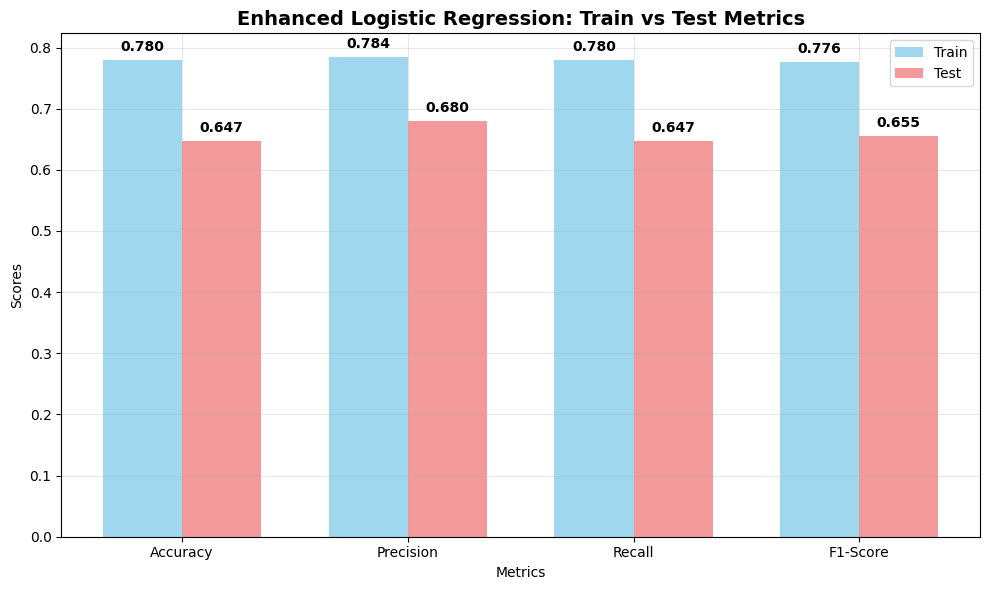

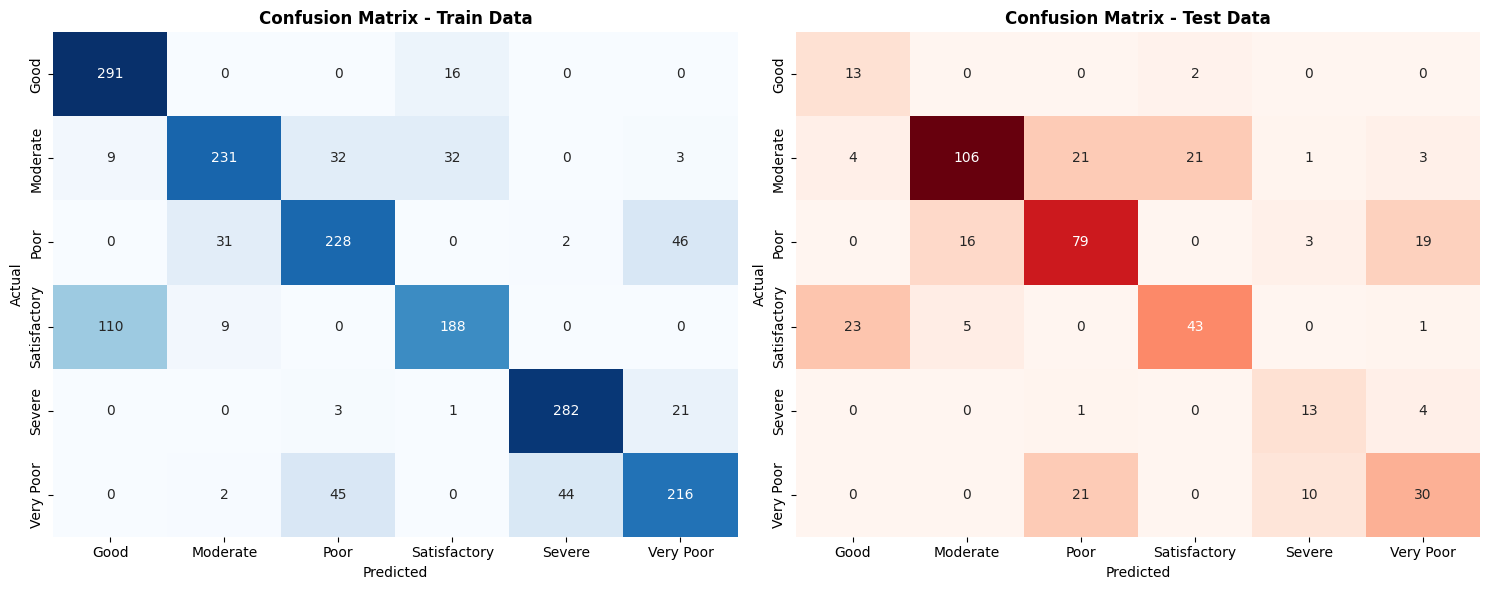

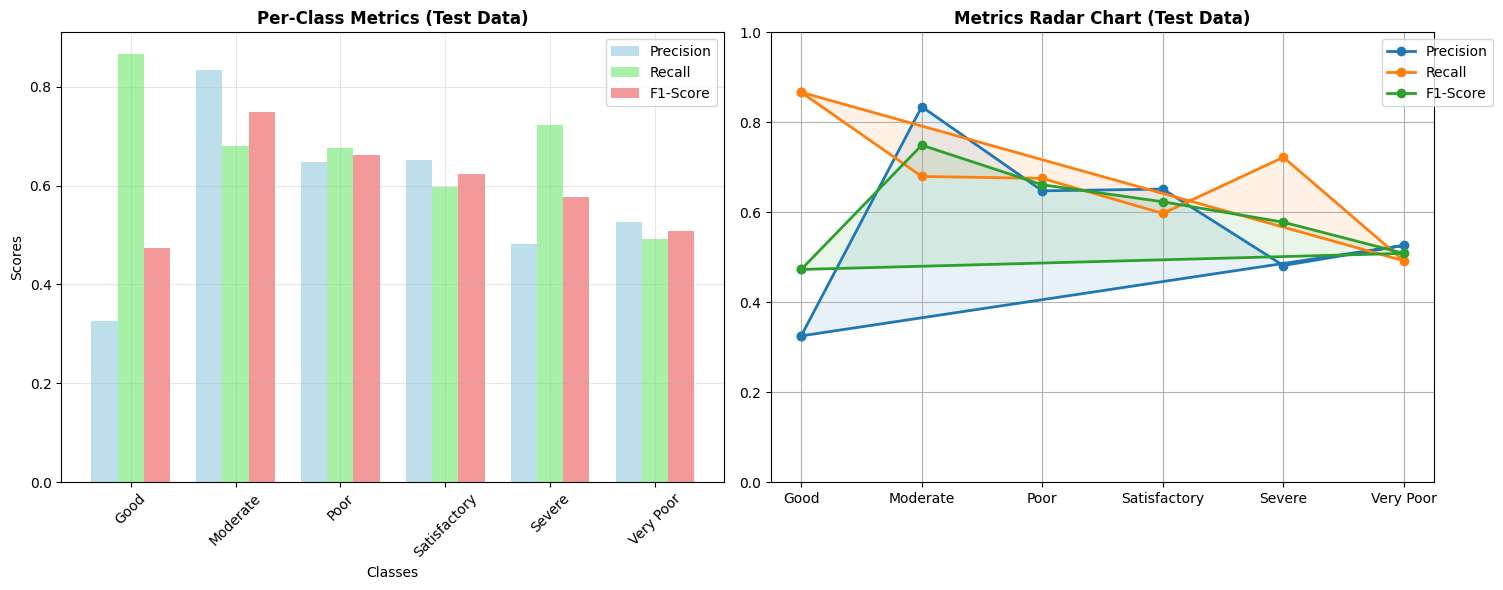

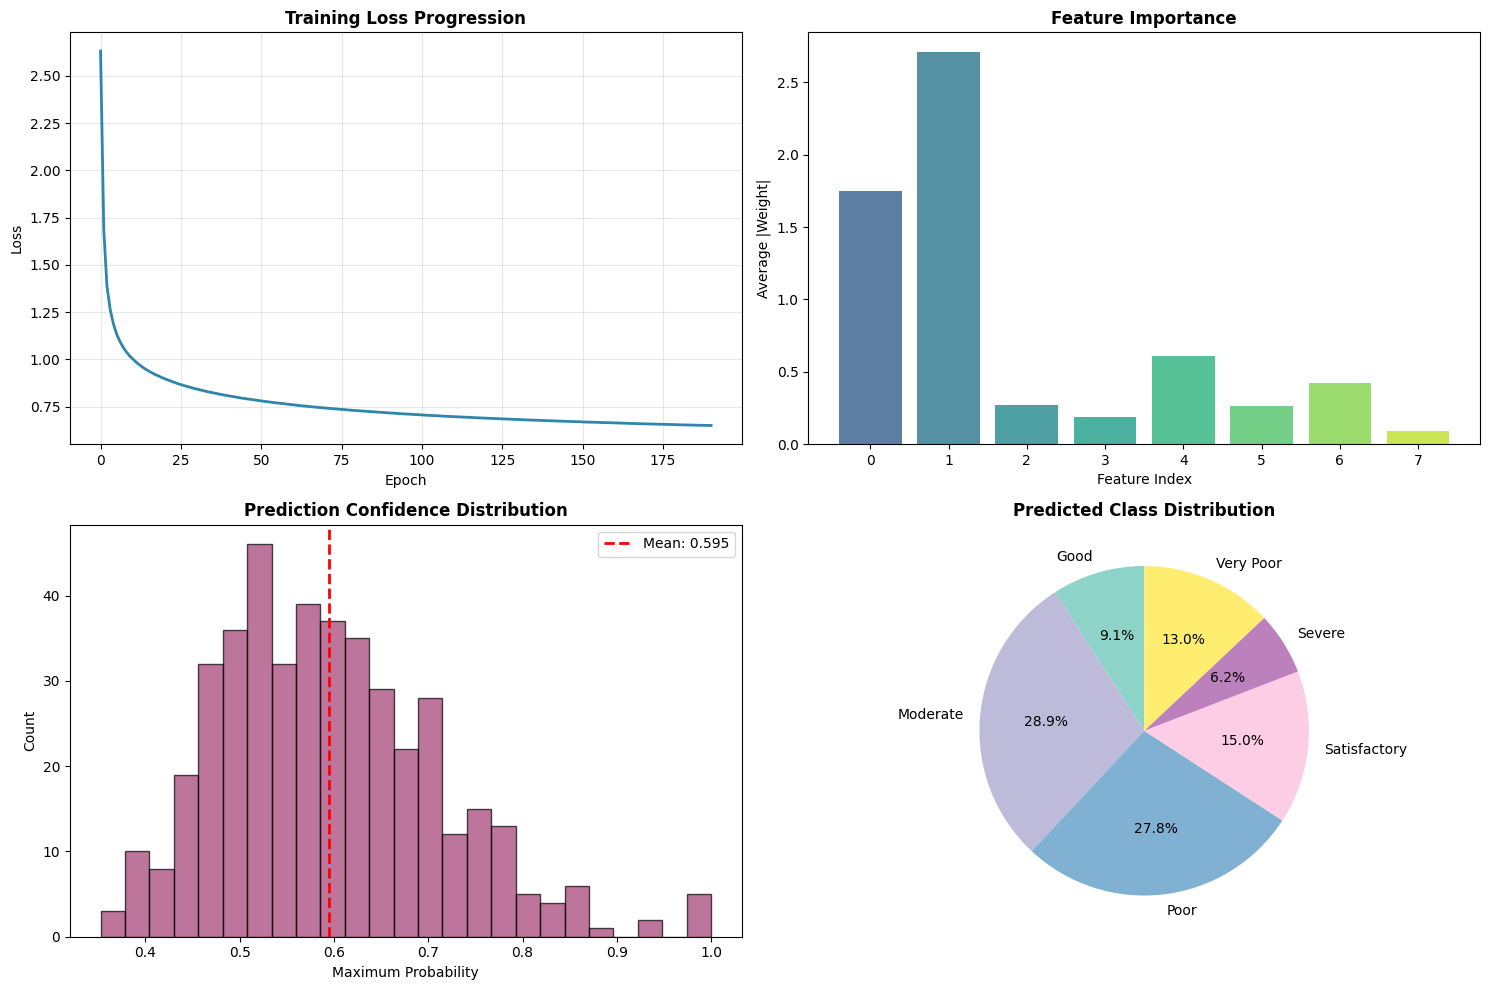


Top 5 Most Important Features:
  1. Feature 1: 2.7104
  2. Feature 0: 1.7476
  3. Feature 4: 0.6128
  4. Feature 6: 0.4207
  5. Feature 2: 0.2691

🎉 DELHI DATASET TRAINING COMPLETE!
   ✨ Final Test Accuracy: 0.6469
   📊 Results Summary:
Dataset  Accuracy  Precision   Recall  F1-Score
  Train  0.779587   0.784070 0.779587  0.776266
   Test  0.646925   0.680007 0.646925  0.655095


In [2]:
# ==================== DELHI AIR QUALITY DATASET ====================

def process_delhi_air_quality_dataset():
    """Process Delhi Air Quality Dataset"""
    print("📂 Loading Delhi Air Quality Dataset...")
    try:
        data = pd.read_csv("delhi_air_quality_dataset.csv")
    except FileNotFoundError:
        print("❌ Delhi dataset not found!")
        return None, None, None

    print(f"✅ Delhi dataset loaded: {data.shape}")
    print(f"   Columns: {data.columns.tolist()}")

    # Handle missing values
    numeric_columns = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
    for col in numeric_columns:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())

    # Create AQI_Bucket based on AQI values
    def categorize_aqi(aqi):
        if aqi <= 50:
            return 'Good'
        elif aqi <= 100:
            return 'Satisfactory'
        elif aqi <= 200:
            return 'Moderate'
        elif aqi <= 300:
            return 'Poor'
        elif aqi <= 400:
            return 'Very Poor'
        else:
            return 'Severe'

    data['AQI_Bucket'] = data['AQI'].apply(categorize_aqi)

    # Prepare features - use all available numeric features except AQI
    feature_columns = [col for col in numeric_columns if col != 'AQI' and col in data.columns]

    # Add categorical features if needed
    if 'Month' in data.columns:
        feature_columns.append('Month')
    if 'Holidays_Count' in data.columns:
        feature_columns.append('Holidays_Count')

    X = data[feature_columns].values
    le_target = LabelEncoder()
    y = le_target.fit_transform(data['AQI_Bucket'])

    print(f"   Features: {feature_columns}")
    print(f"   Samples: {len(X)}")
    print(f"   Classes: {le_target.classes_}")
    print(f"   Class distribution: {Counter(y)}")

    return X, y, le_target, "Delhi Air Quality"

def run_delhi_experiment():
    """Run complete experiment on Delhi dataset"""
    print("="*70)
    print("🚀 DELHI AIR QUALITY DATASET EXPERIMENT")
    print("="*70)

    X, y, le_target, dataset_name = process_delhi_air_quality_dataset()

    if X is None:
        return

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    print(f"   Train samples: {X_train.shape[0]}")
    print(f"   Test samples: {X_test.shape[0]}")
    print(f"   Features: {X_train.shape[1]}")
    print(f"   Train class distribution: {Counter(y_train)}")

    # Apply SMOTE for data balancing
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"   After SMOTE - Train samples: {X_train_smote.shape[0]}")
    print(f"   After SMOTE - Class distribution: {Counter(y_train_smote)}")

    # Train and evaluate model
    model, train_metrics, test_metrics, params = evaluate_model(
        X_train_smote, X_test, y_train_smote, y_test, le_target
    )

    # Save results
    results_df = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Accuracy': [train_metrics['accuracy'], test_metrics['accuracy']],
        'Precision': [train_metrics['precision'], test_metrics['precision']],
        'Recall': [train_metrics['recall'], test_metrics['recall']],
        'F1-Score': [train_metrics['f1'], test_metrics['f1']]
    })

    print(f"\n🎉 DELHI DATASET TRAINING COMPLETE!")
    print(f"   ✨ Final Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   📊 Results Summary:")
    print(results_df.to_string(index=False))

    return model, train_metrics, test_metrics

# Run Delhi experiment
delhi_model, delhi_train_metrics, delhi_test_metrics = run_delhi_experiment()